# NeidExtractor Example

Import the libaries:

In [2]:
from neid_extractor import NeidExtractor,MultipleNeid
from pathlib import Path


## Handling One file

In [ ]:
# Define the path to file
flname = Path("path/to/fits/file.fits")

# Create the instance and open the file
neid_ex = NeidExtractor(flname)

Getting FITS information:

In [4]:
neid_ex.info()

Filename: ../../GaiaDR3751738/neidL2_20250528T050024.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     834   ()      
  1  SCIFLUX       1 ImageHDU        13   (9216, 122)   float64   
  2  SKYFLUX       1 ImageHDU        13   (9216, 122)   float64   
  3  CALFLUX       1 ImageHDU        13   (9216, 122)   float64   
  4  SCIVAR        1 ImageHDU        12   (9216, 122)   float32   
  5  SKYVAR        1 ImageHDU        12   (9216, 122)   float32   
  6  CALVAR        1 ImageHDU        12   (9216, 122)   float32   
  7  SCIWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  8  SKYWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  9  CALWAVE       1 ImageHDU      2451   (9216, 122)   float64   
 10  TELLURIC      1 ImageHDU        20   (2, 9216, 122)   float64   
 11  SKY           1 ImageHDU         8   ()      
 12  CCFS          1 ImageHDU       531   (804, 122)   float64   
 13  ACTIVITY      1 BinTableHDU     37

Search for the HDU name and its index:

In [11]:
neid_ex.search_hdus(wave="SCIWAVE", flux="SCIFLUX")

{'wave': 7, 'flux': 1}

Check the full header on a HDU:

In [12]:
neid_ex.check_header(0)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
CHECKSUM= 'nASop9SmnASmn7Sm'   / HDU checksum updated 2025-05-29T01:48:37       
DATASUM = '0       '           / data unit checksum updated 2025-05-28T18:52:46 
ORIGIN  = 'astropy.io.fits'    / File Originator                                
INSTRUME= 'NEID    '           / Instrument Name                                
DATALVL =                    2 / Data Product Base Level                        
DATATMP =                    F / Data Temporary Intermediate Product            
OBSERVER= 'Higuera '           / Observer Name                                  
TIMESYS = 'UTC     '           / Time Scale                                     
PROGRAM = '2025A-640649'    

Search in all headers for a string:

In [14]:
neid_ex.search_hdu_header("NAXIS1")

Search string NAXIS1 returned:
False for HDU=0
True for HDU=1
True for HDU=2
True for HDU=3
True for HDU=4
True for HDU=5
True for HDU=6
True for HDU=7
True for HDU=8
True for HDU=9
True for HDU=10
False for HDU=11
True for HDU=12
True for HDU=13
True for HDU=14
True for HDU=15
True for HDU=16
True for HDU=17


Search for a string in a header and its value:

In [15]:
neid_ex.find_in_header(1, "NAXIS1")

NAXIS1  =                 9216                                                  


Define an order to use:

This must be done before assigning any data.

In [40]:
neid_ex.order = 101

To check how many orders are available, use:

The `[1]` is the HDU containing flux or wavelength.

In [41]:
len(neid_ex.fits[1].data)

122

Build wavelength solution based on header values:
This in only necessary if the FITS file does not have wavelength data.

In [42]:
neid_ex.build_wave(7, naxis="NAXIS1", crval="CRVAL1", cdelt="CDELT1")

neid_ex.wavelength

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 9.213e+03, 9.214e+03,
       9.215e+03], shape=(9216,))

Assign wavelength and flux data:

In [43]:
neid_ex.assign_wave(7)
neid_ex.assign_flux(1)

neid_ex.wavelength, neid_ex.flux

(array([8432.24759844, 8432.27059016, 8432.29358066, ..., 8594.26445841,
        8594.27677958, 8594.2890996 ], shape=(9216,), dtype='>f8'),
 array([277.18566895, 323.074646  , 322.03094482, ..., 185.04733276,
        181.08230591, 198.92553711], shape=(9216,), dtype='>f8'))

### Auto Make Spectrum

This will search in the HDUs and assign wavelength and flux automatically:

In [46]:
neid_ex.auto_make_spectrum(wave_hdu="SCIWAVE", flux_hdu="SCIFLUX")

neid_ex.wavelength, neid_ex.flux

(array([8432.24759844, 8432.27059016, 8432.29358066, ..., 8594.26445841,
        8594.27677958, 8594.2890996 ], shape=(9216,), dtype='>f8'),
 array([277.18566895, 323.074646  , 322.03094482, ..., 185.04733276,
        181.08230591, 198.92553711], shape=(9216,), dtype='>f8'))

It is also possible to enable the build_wave function:

In [45]:
neid_ex.auto_make_spectrum(flux_hdu="SCIFLUX", build_wave=True, 
                           build_wave_hdu=7, naxis="NAXIS1", 
                           crval="CRVAL1", cdelt="CDELT1")

neid_ex.wavelength, neid_ex.flux

(array([0.000e+00, 1.000e+00, 2.000e+00, ..., 9.213e+03, 9.214e+03,
        9.215e+03], shape=(9216,)),
 array([277.18566895, 323.074646  , 322.03094482, ..., 185.04733276,
        181.08230591, 198.92553711], shape=(9216,), dtype='>f8'))

### Plot and Save

File names can be passed as arguments or be None. The former will trigger the code to create automatically based on the original file name and save it under the same directory as the FITS file.

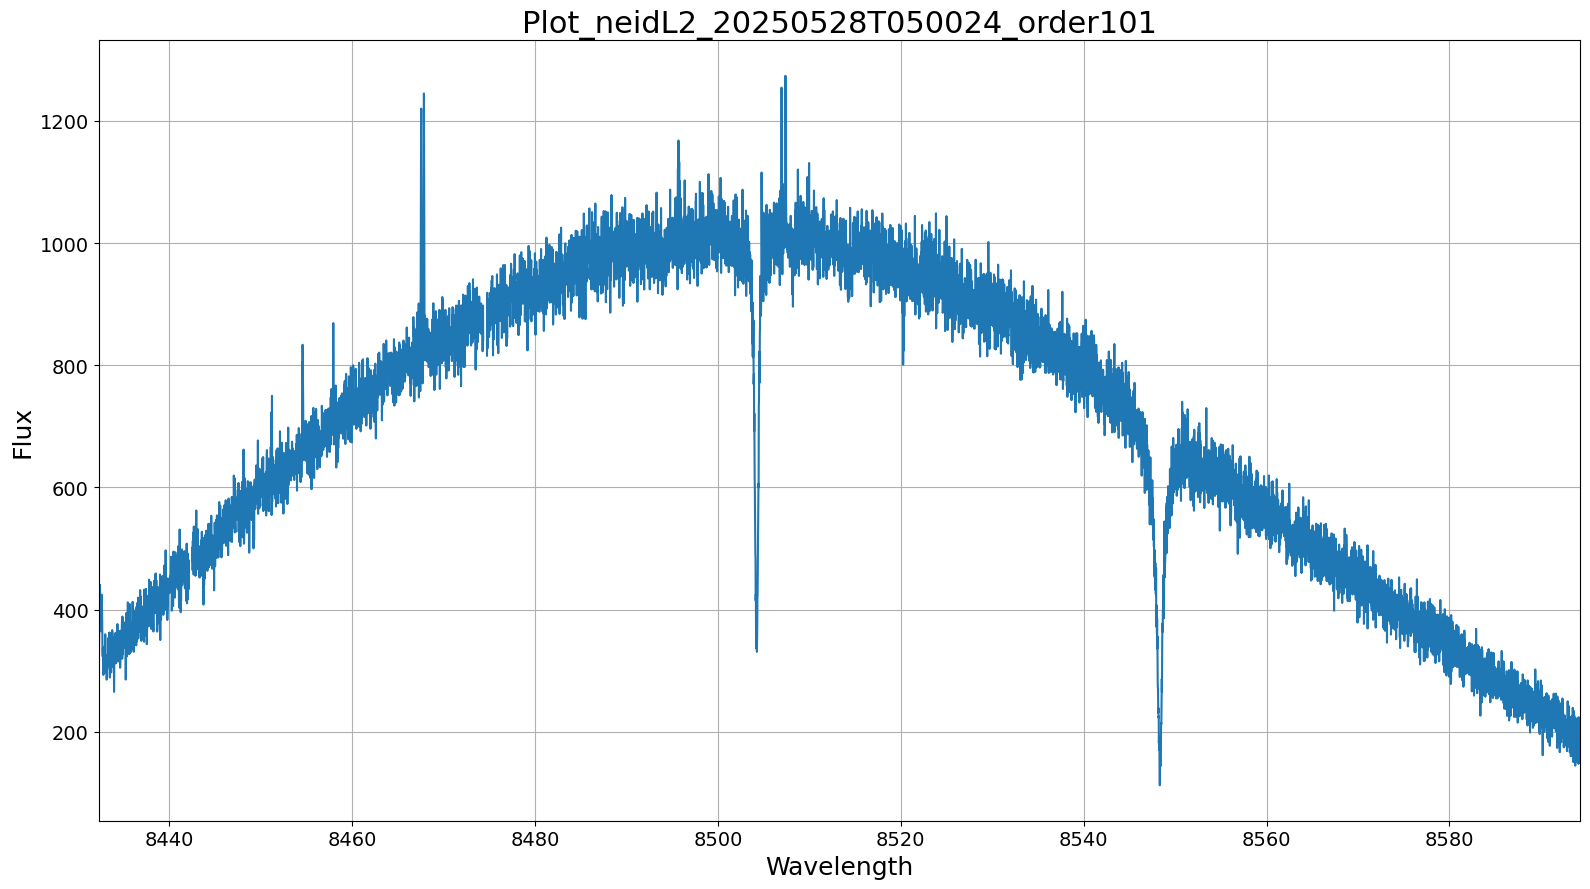

In [ ]:
neid_ex.plot_spec(fl_name=None, plot=True, save=False)

In [ ]:
neid_ex.save_spec(fl_name=None, delimiter=",", fmt="%.5f")

## Handling Multiple files

In [ ]:
# Define the path to file
dirname = Path("path/to/directory")

# Create the instance and open the files
neid_multi = MultipleNeid(dirname)

# Define order
neid_multi.order = 101

Check how many files are open:

In [51]:
len(neid_multi)

5

Get only one file and work as if it was opened by the NeidExtractor() class:

In [52]:
single = neid_multi[0]
single.info()

Filename: ../../GaiaDR3751738/neidL2_20250529T043808.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     834   ()      
  1  SCIFLUX       1 ImageHDU        13   (9216, 122)   float64   
  2  SKYFLUX       1 ImageHDU        13   (9216, 122)   float64   
  3  CALFLUX       1 ImageHDU        13   (9216, 122)   float64   
  4  SCIVAR        1 ImageHDU        12   (9216, 122)   float32   
  5  SKYVAR        1 ImageHDU        12   (9216, 122)   float32   
  6  CALVAR        1 ImageHDU        12   (9216, 122)   float32   
  7  SCIWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  8  SKYWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  9  CALWAVE       1 ImageHDU      2451   (9216, 122)   float64   
 10  TELLURIC      1 ImageHDU        20   (2, 9216, 122)   float64   
 11  SKY           1 ImageHDU         8   ()      
 12  CCFS          1 ImageHDU       531   (804, 122)   float64   
 13  ACTIVITY      1 BinTableHDU     37

Get info about all files:

In [53]:
neid_multi.info()

Filename: ../../GaiaDR3751738/neidL2_20250529T043808.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     834   ()      
  1  SCIFLUX       1 ImageHDU        13   (9216, 122)   float64   
  2  SKYFLUX       1 ImageHDU        13   (9216, 122)   float64   
  3  CALFLUX       1 ImageHDU        13   (9216, 122)   float64   
  4  SCIVAR        1 ImageHDU        12   (9216, 122)   float32   
  5  SKYVAR        1 ImageHDU        12   (9216, 122)   float32   
  6  CALVAR        1 ImageHDU        12   (9216, 122)   float32   
  7  SCIWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  8  SKYWAVE       1 ImageHDU      2451   (9216, 122)   float64   
  9  CALWAVE       1 ImageHDU      2451   (9216, 122)   float64   
 10  TELLURIC      1 ImageHDU        20   (2, 9216, 122)   float64   
 11  SKY           1 ImageHDU         8   ()      
 12  CCFS          1 ImageHDU       531   (804, 122)   float64   
 13  ACTIVITY      1 BinTableHDU     37

### Auto Make for all files

The same arguments from the `auto_make_spectrum` can be used.

In [54]:
neid_multi.auto_make_all()

### Plot and save all

In [55]:
neid_multi.plot_all(plot=False, save=True)

In [56]:
neid_multi.save_all(fl_name=None, delimiter=",", fmt="%.5f")